# Imports

In [3]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 528.6 kB/s eta 0:01:16
    --------------------------------------- 0.5/40.2 MB 528.6 kB/s eta 0:01:16
    --------------------------------------- 0.8/40.2 MB 490.0 kB/s eta 0:01:21
    --------------------------------------- 0.8/40.2 MB 490.0 kB/s eta 0:01:21
    --------------------------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [6]:
import sys
print(sys.executable)
!{sys.executable} -m pip show opencv-python

c:\Users\nitee\AppData\Local\Programs\Python\Python312\python.exe


In [9]:
%pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter
from PIL import Image

# Load Labels

In [12]:
import json

with open("../gcp_marks.json") as f:
    labels = json.load(f)

print("Total Samples:", len(labels))

Total Samples: 1000


# Shape Distribution

In [14]:
shapes = [
    v["verified_shape"]
    for v in labels.values()
]

shape_counts = Counter(shapes)

print(shape_counts)

KeyError: 'verified_shape'

In [15]:
missing = [k for k, v in labels.items() if "verified_shape" not in v]
print("Missing verified_shape:", missing[:20])

Missing verified_shape: ['Seashell Ras el Hekma/Survey 3/GCP12/DJI_20240605112759_0254.JPG', 'Vedanta GOA Bicholim/MCDR 2024/GCP32/19_4_DJI_0066.JPG', 'Vedanta GOA Bicholim/MCDR 2024/GCP17/12_2_DJI_0558.JPG', 'UTCL UNCL Additional Area/Survey-1/GCP-98/DJI_20240425131303_0192_V.JPG']


In [16]:
missing = [
    k for k,v in labels.items()
    if "verified_shape" not in v
]

print(len(missing))

4


# Inspect each missing sample

In [17]:
for path in missing:
    print(path)
    print(labels[path])
    print()

Seashell Ras el Hekma/Survey 3/GCP12/DJI_20240605112759_0254.JPG
{'mark': {'x': 2674.8615461670306, 'y': 427.01017187573916}}

Vedanta GOA Bicholim/MCDR 2024/GCP32/19_4_DJI_0066.JPG
{'mark': {'x': 3191.64937365544, 'y': 1634.5713599497808}}

Vedanta GOA Bicholim/MCDR 2024/GCP17/12_2_DJI_0558.JPG
{'mark': {'x': 507.906900565024, 'y': 2123.0392188877872}}

UTCL UNCL Additional Area/Survey-1/GCP-98/DJI_20240425131303_0192_V.JPG
{'mark': {'x': 1924.1735694119093, 'y': 267.03431372548926}}



In [18]:
shapes = [
    v["verified_shape"]
    for v in labels.values()
    if "verified_shape" in v
]

Dataset Observation:

4 samples contain coordinate annotations but are missing
the "verified_shape" field.

Assumption:
These samples will be excluded from training to ensure
consistent supervision for the multi-task model.

In [20]:
valid_samples = [
    k for k,v in labels.items()
    if "verified_shape" in v
]

print("Valid Samples:", len(valid_samples))
print("Missing Shape:", len(missing))

Valid Samples: 996
Missing Shape: 4


# Shapes count

In [19]:
from collections import Counter

shape_counts = Counter(shapes)

print(shape_counts)

Counter({'L-Shape': 491, 'Square': 328, 'Cross': 177})


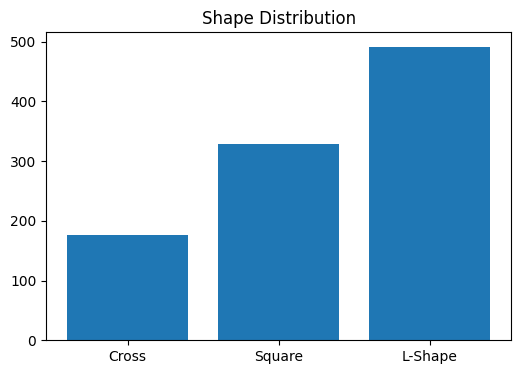

In [21]:
plt.figure(figsize=(6,4))

plt.bar(
    shape_counts.keys(),
    shape_counts.values()
)

plt.title("Shape Distribution")
plt.show()

# Image Dimensions

In [22]:
train_root = Path("../data/train_dataset")

sizes = []

for img_path in train_root.rglob("*.JPG"):
    
    img = Image.open(img_path)
    
    sizes.append(img.size)

Counter(sizes)

Counter({(4096, 2730): 642, (4096, 3068): 358})

# Co-ordinate Distribution

In [23]:
xs = []
ys = []

for v in labels.values():
    
    xs.append(v["mark"]["x"])
    ys.append(v["mark"]["y"])

print(min(xs), max(xs))
print(min(ys), max(ys))

66.96412957110547 3937.0554836417386
35.044623574285524 2914.109404383081


# Plot to find any clusterrs

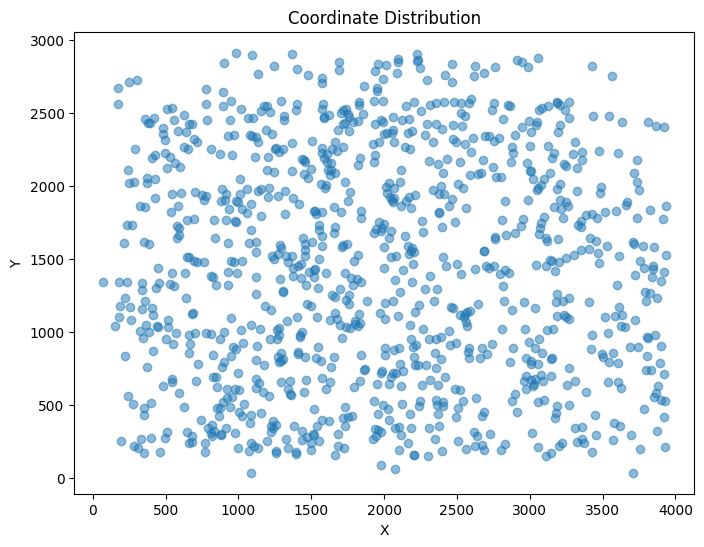

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(xs, ys, alpha=0.5)

plt.title("Coordinate Distribution")

plt.xlabel("X")
plt.ylabel("Y")

plt.show()

# Normalized Co-ordinates

In [29]:
from pathlib import Path
import cv2

norm_x = []
norm_y = []

train_root = Path("../data/train_dataset")

for path, info in labels.items():

    img_path = train_root / path

    img = cv2.imread(str(img_path))

    h, w = img.shape[:2]

    x = info["mark"]["x"]
    y = info["mark"]["y"]

    norm_x.append(x / w)
    norm_y.append(y / h)

print("Done")

Done


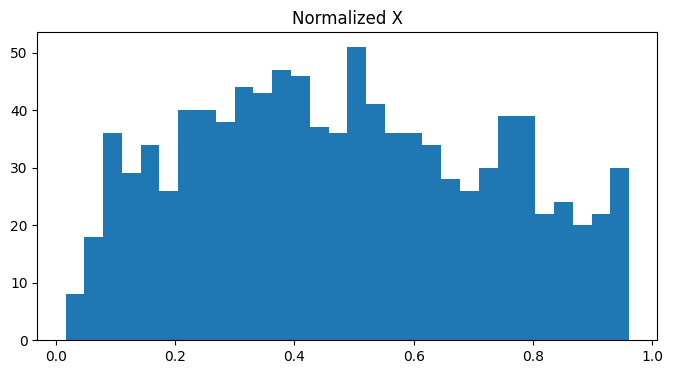

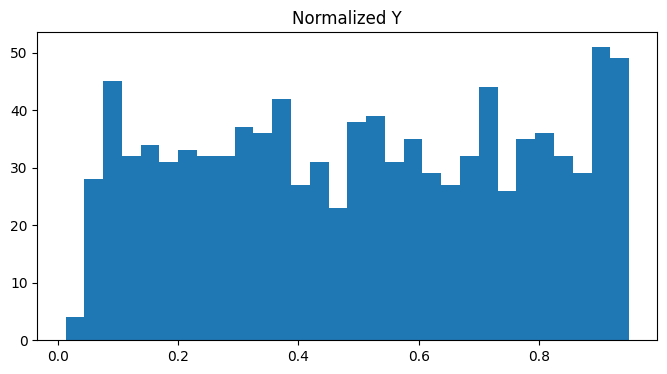

In [30]:
plt.figure(figsize=(8,4))
plt.hist(norm_x, bins=30)
plt.title("Normalized X")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(norm_y, bins=30)
plt.title("Normalized Y")
plt.show()

# Random Visual Inspection

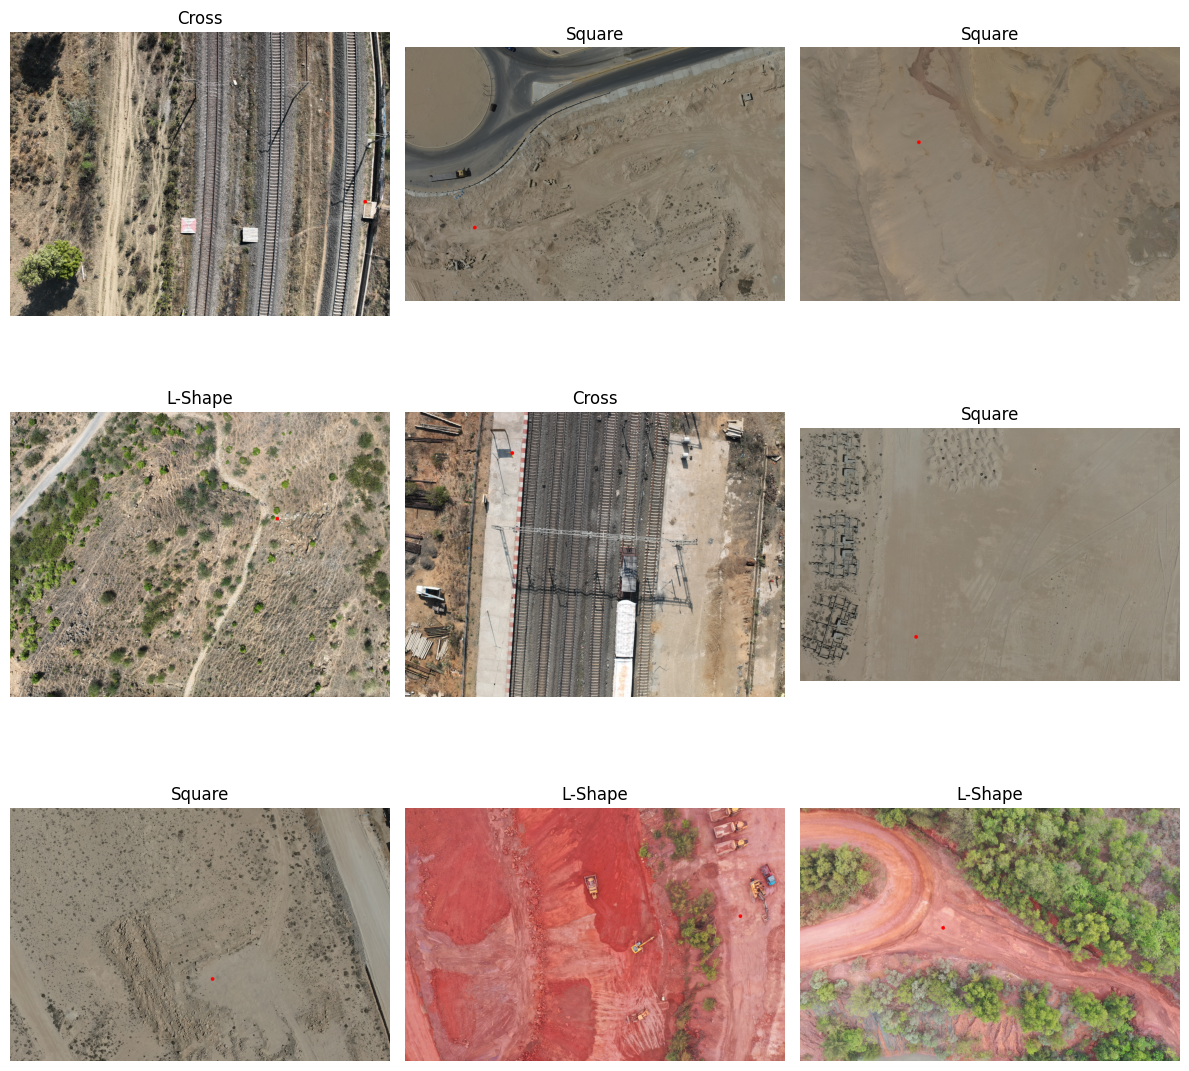

In [26]:
import random

sample_paths = random.sample(
    list(labels.keys()),
    9
)

fig, axes = plt.subplots(
    3,3,
    figsize=(12,12)
)

for ax,path in zip(
    axes.flatten(),
    sample_paths
):
    
    img_path = (
        Path("../data/train_dataset")
        / path
    )
    
    img = cv2.imread(str(img_path))
    
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    x = labels[path]["mark"]["x"]
    y = labels[path]["mark"]["y"]

    shape = labels[path]["verified_shape"]

    cv2.circle(
        img,
        (int(x),int(y)),
        20,
        (255,0,0),
        -1
    )

    ax.imshow(img)

    ax.set_title(shape)

    ax.axis("off")

plt.tight_layout()

plt.show()

# Project Distribution

In [27]:
projects = []

for path in labels.keys():
    
    project = path.split("/")[0]
    
    projects.append(project)

project_counts = Counter(projects)

print(
    pd.Series(project_counts)
    .sort_values(
        ascending=False
    )
    .head(20)
)

Vedanta GOA Bicholim                254
UTCL UNCL Additional Area           199
Seashell Ras el Hekma               153
Adani GP-III CG                     105
231129_CTD                           85
Egypt-New city                       71
scout_966                            52
Deora Limestone Mine                 41
RDCW-Reddipalayam Limestone Mine     29
scout_971                            10
scout_973                             1
dtype: int64


# Sanity Check

In [31]:
count = 0

for path, info in labels.items():

    img_path = Path("../data/train_dataset") / path

    img = cv2.imread(str(img_path))

    h, w = img.shape[:2]

    x = info["mark"]["x"]
    y = info["mark"]["y"]

    if x > w or y > h:
        count += 1
        print(path, x, y, w, h)

print("Invalid samples:", count)

Invalid samples: 0


# Zoomed Crop Visualization

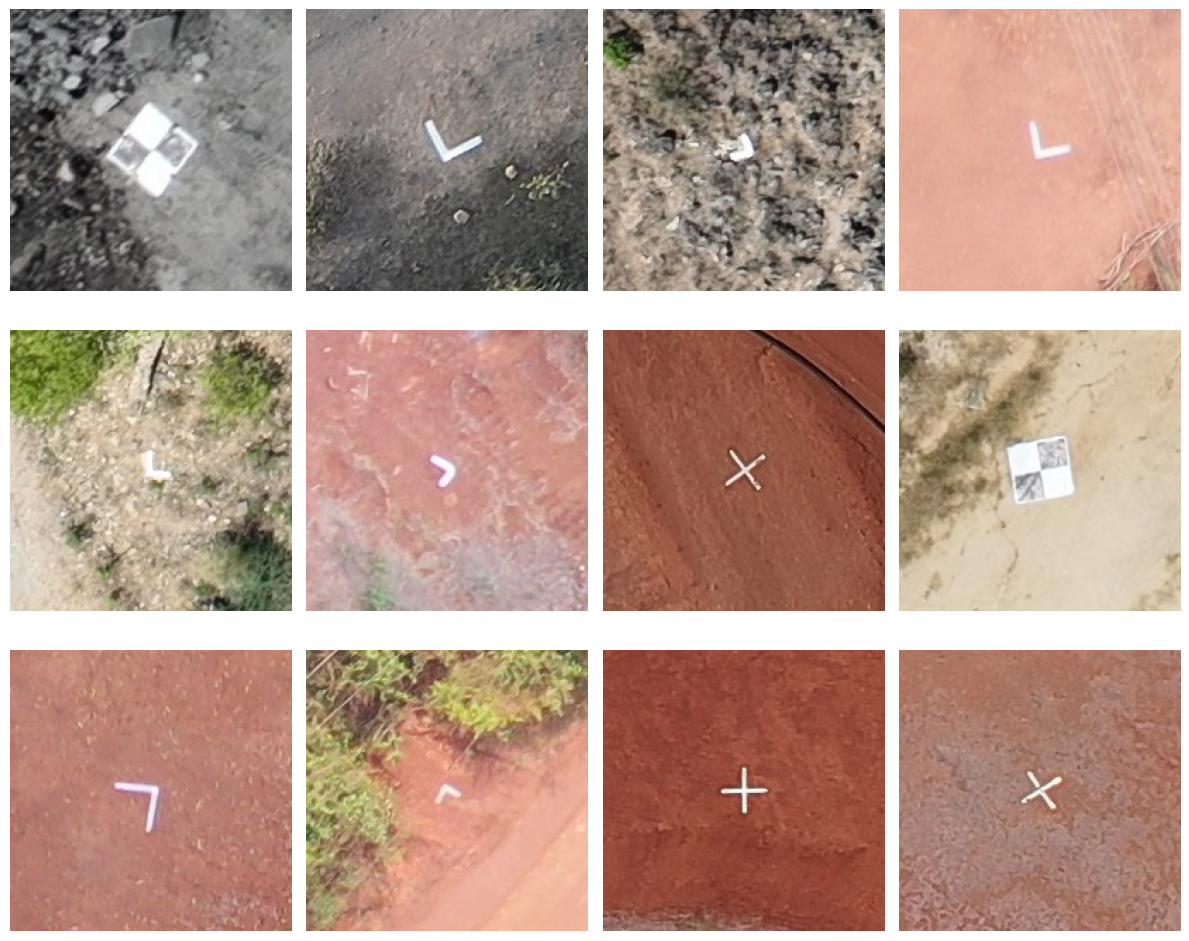

In [33]:
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

samples = random.sample(
    list(labels.keys()),
    12
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12,10)
)

for ax, path in zip(
    axes.flatten(),
    samples
):

    img_path = (
        Path("../data/train_dataset")
        / path
    )

    img = cv2.imread(str(img_path))

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    x = int(labels[path]["mark"]["x"])
    y = int(labels[path]["mark"]["y"])

    crop_size = 100

    x1 = max(0, x-crop_size)
    y1 = max(0, y-crop_size)

    x2 = min(img.shape[1], x+crop_size)
    y2 = min(img.shape[0], y+crop_size)

    crop = img[y1:y2, x1:x2]

    ax.imshow(crop)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [34]:
for path in random.sample(list(labels.keys()), 5):

    img_path = (
        Path("../data/train_dataset")
        / path
    )

    img = cv2.imread(str(img_path))

    print(path)
    print(img.shape)
    print(labels[path]["mark"])
    print()

UTCL UNCL Additional Area/Survey-1/GCP-64/DJI_20240424162441_0273_V.JPG
(3068, 4096, 3)
{'x': 1090.1146815533898, 'y': 2899.0310415490953}

UTCL UNCL Additional Area/Survey-1/GCP-42/DJI_20240422142343_0185_V.JPG
(3068, 4096, 3)
{'x': 1924.3268603761717, 'y': 2286.7260933466982}

UTCL UNCL Additional Area/Survey-1/GCP-65/DJI_20240424164113_0051_V.JPG
(3068, 4096, 3)
{'x': 1516.0740857835472, 'y': 473.20295738685047}

Vedanta GOA Bicholim/MCDR 2024/GCP07/27_5_DJI_0534.JPG
(2730, 4096, 3)
{'x': 2187.364549923369, 'y': 949.6981946924823}

UTCL UNCL Additional Area/Survey-1/GCP-44/DJI_20240422140311_0294_V.JPG
(3068, 4096, 3)
{'x': 1571.8888774629663, 'y': 2530.4506654539377}



# Findings


1. Dataset contains 1000 samples.

2. Four samples are missing shape labels.

3. Marker coordinates are distributed across the entire image.

4. Images have two resolutions:
   4096×2730 and 4096×3068.

5. Marker size is approximately 40–50 pixels.

6. Marker shapes are visually distinguishable.

7. Shape classification is expected to be easier than localization.

8. Localization is the primary challenge.